In [22]:
from google.colab import drive
drive.mount('/content/drive')
%cd ..
%cd /content/drive/MyDrive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive
/content/drive/MyDrive


In [23]:
!pwd
!ls

/content/drive/MyDrive
 best_model.pkl
 bimlendr_arpit_assignment1_bonus.ipynb
 bimlendr_arpitmit_assignment1_part1_diamond.ipynb
 bimlendr_arpitmit_assignment1_part_3_ridge_regression.ipynb
 bimlendr_arpitmit_assignment1_part3_ridgeregressionmodel.pickle
'bimlendr_assignment0_final (1).ipynb'
 bimlendr_Final_part4main.ipynb
 bonus.ipynb
'Colab Notebooks'
 compressed_image1.png
'Contact Information.gform'
'Copy of bimlendr_arpit_assignment1_part1_emission.ipynb'
'Copy of Bimlendr_Assignment1_checkpoint_diamond.ipynb'
'Copy of Bimlendr_Assignment1_checkpoint_emissionbycountry.ipynb'
 diamond.csv
 diamond_processed.csv
 emissions_by_country.csv
 emissions_by_country_processed.csv
 image1_done.png
 image1.png
 image2_done.png
 image2.png
 linear_regression.csv
 linear_regression_done.csv
 New_York_State_Statewide_COVID-19_Testing__Archived__20241009.csv
 penguins.csv
 recolored_image2.png
'Untitled document.gdoc'


In [24]:
# 1. Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

In [25]:
# 2. Data analysis and preprocessing - reusing our preprocessing code from Part I
df = pd.read_csv('emissions_by_country.csv')

# Handle missing entries
numColumns = ['Year', 'Total', 'Temperature', 'GDP Per Capita (USD)', 'Coal', 'Oil', 'Gas', 'Cement', 'Flaring', 'Other', 'Per Capita']
df[numColumns] = df[numColumns].apply(pd.to_numeric,errors='coerce')
dfMean = df.copy()
dfMean[numColumns] = dfMean[numColumns].fillna(dfMean[numColumns].mean())

# Handle mismatched string formats.
dfMean['Country'] = dfMean['Country'].str.upper()
dfMean['ISO 3166-1 alpha-3'] = dfMean['ISO 3166-1 alpha-3'].str.upper()

# Handle outliers.
def detectOutliers(df, column):
    quartile1 = df[column].quantile(0.25)
    quartile3 = df[column].quantile(0.75)
    interQuartileRange = quartile3 - quartile1
    lowerLimit = quartile1 - (1.5 * interQuartileRange)
    upperLimit = quartile3 + (1.5 * interQuartileRange)
    outliers = df[(df[column] < lowerLimit) | (df[column] > upperLimit)]
    return outliers, lowerLimit, upperLimit

outliers, lower, upper = detectOutliers(dfMean, 'Per Capita')
new_df = dfMean.copy()
mean_PCapita = new_df[(new_df['Per Capita'] >= lower) & (new_df['Per Capita'] <= upper)]['Per Capita'].mean()
new_df['Per Capita'] = new_df['Per Capita'].apply(
    lambda x: mean_PCapita if x < lower or x > upper else x
)
print('outliers based on Per Capita', len(outliers))
print('new_df size', len(new_df))

# Identify uncorrelated or unrelated features.
correlation = new_df[['Total', 'GDP Per Capita (USD)', 'Coal', 'Oil', 'Gas', 'Cement', 'Flaring', 'Per Capita']].corr()
medianTotal = new_df['Total'].median()
new_df['High_Emissions'] = np.where(new_df['Total'] > medianTotal, 1, 0)
numberColumn = new_df.select_dtypes(include=[np.number])
correlationMatrix = numberColumn.corr()
correlationHE = correlationMatrix['High_Emissions'].sort_values(ascending=False)
threshold = 0.1
lowerCorrelations = correlationHE[correlationHE.abs() < threshold].index.tolist()
df_ToDrop = new_df.copy()
df_ToDrop = df_ToDrop.drop(columns=lowerCorrelations)

# Convert features with string datatype to categorical
onHotEncoding = pd.get_dummies(df_ToDrop, columns=['Country', 'ISO 3166-1 alpha-3'], drop_first=True)

outliers based on Per Capita 1158
new_df size 63104


In [26]:
# 3. Data preparation

# Defining input and target variable
X = onHotEncoding.drop(columns=['Per Capita']).values
Y = new_df['Per Capita'].values.reshape(-1, 1)

# Spliting data to 80% for training and 20% for testing
totalSample = X.shape[0]
splitBoundary = int(0.8 * totalSample)
X_train = X[:splitBoundary]
y_train = Y[:splitBoundary]
X_test = X[splitBoundary:]
y_test = Y[splitBoundary:]

print(f"x training data shape: {X_train.shape}, y training data shape: {y_train.shape}")
print(f"x testing data shape: {X_test.shape}, y testing data shape: {y_test.shape}")

# Normalization of data
def normalization(data):
    dataMin = data.min(axis=0)
    dataMax = data.max(axis=0)
    dataRange = dataMax - dataMin
    dataRange[dataRange == 0] = 1
    normalizedData = (data - dataMin) / dataRange
    return normalizedData, dataMin, dataMax

X_train_normalized, dataMin, dataMax = normalization(X_train)
range = dataMax - dataMin
range[range == 0] = 1
X_test_normalized = (X_test - dataMin) / range
X_train_normalized = X_train_normalized.astype(np.float64)
X_test_normalized = X_test_normalized.astype(np.float64)
y_train = y_train.astype(np.float64)
y_test = y_test.astype(np.float64)

x training data shape: (50483, 460), y training data shape: (50483, 1)
x testing data shape: (12621, 460), y testing data shape: (12621, 1)


In [27]:
# 5. Ridge Regression using OLS
def ridgeRegression(xTrainDataNormalized, yTrainData, lambdaValue):
    totalFeatures = xTrainDataNormalized.shape[1]
    identityMatrix = np.identity(totalFeatures)

    # calculating (X^T * X + λI)^(-1)
    transposeProductWithX = np.dot(xTrainDataNormalized.T, xTrainDataNormalized)
    regTerm = lambdaValue * identityMatrix
    inverse_term = np.linalg.inv(transposeProductWithX + regTerm)

    # calculating weight
    transposeProductWithY = np.dot(xTrainDataNormalized.T, yTrainData)
    weight = np.dot(inverse_term, transposeProductWithY)

    # Calculating loss
    N = len(yTrainData)
    y_pred = np.dot(xTrainDataNormalized, weight)
    error = yTrainData - y_pred
    loss = (1 / (2 * N)) * np.sum(error ** 2) + (lambdaValue / 2) * np.sum(weight**2)
    return weight, loss

lambdaValue = 0.01
X_train_normalized = np.column_stack([np.ones(X_train_normalized.shape[0]), X_train_normalized])
X_test_normalized = np.column_stack([np.ones(X_test_normalized.shape[0]), X_test_normalized])
weight, loss = ridgeRegression(X_train_normalized, y_train, lambdaValue)
print("ridge regression weight: \n", weight)

ridge regression weight: 
 [[ 1.72748016e+02]
 [-1.16830488e+02]
 [ 1.14243938e+02]
 [ 1.20398507e+01]
 [ 4.14085125e+01]
 [-8.33121537e+01]
 [-1.78483105e+01]
 [ 1.01228277e+01]
 [-2.61488172e+01]
 [-1.30933456e+01]
 [-1.64284245e+01]
 [-2.36265757e+01]
 [-7.70177117e+00]
 [ 5.17057661e+00]
 [ 1.66833624e+01]
 [-9.83171356e+00]
 [-2.59864214e+01]
 [-2.57388029e+01]
 [-4.18869174e+00]
 [-1.47669321e+01]
 [-1.88572235e+01]
 [ 1.33333977e+00]
 [-2.52719609e+00]
 [-4.14282645e+00]
 [-1.87871617e+01]
 [-5.35890539e+00]
 [ 2.37514878e+01]
 [ 6.62604190e+00]
 [-4.83269276e+00]
 [-3.29232061e+00]
 [ 2.90878325e+00]
 [ 1.16636258e+01]
 [-1.05774645e+01]
 [ 4.78401729e+00]
 [-1.02286053e+01]
 [-8.50166058e+00]
 [-1.48702279e+01]
 [-2.38554364e+01]
 [ 1.57268045e+01]
 [-1.14183154e+01]
 [ 1.90870730e+01]
 [-1.87324409e+00]
 [ 9.25558600e-01]
 [-1.49282555e+01]
 [-1.30855541e+01]
 [ 8.35519571e+00]
 [-1.74783139e+01]
 [-2.68438932e+01]
 [-2.02050660e+01]
 [-1.21431519e+01]
 [-1.16329933e+01]
 [-9

In [28]:
with open('bimlendr_arpitmit_assignment1_part3_ridgeregressionmodel.pickle', 'wb') as f:
    pickle.dump(weight, f)

In [29]:
def regularizedSquaredLoss(DataNormalized, actualData, weight, lambdaValue):
    N = len(actualData)
    predictedData = np.dot(DataNormalized, weight)
    error = actualData - predictedData
    loss = (1 / (2 * N)) * np.sum(error ** 2) + (lambdaValue / 2) * np.sum(weight**2)
    return loss

mseOnTrain = regularizedSquaredLoss(X_train_normalized, y_train, weight, 0.01)
mseOnTest = regularizedSquaredLoss(X_test_normalized, y_test, weight, 0.01)

print("MSE on Training Data: ", mseOnTrain)
print("MSE on Testing Data : ", mseOnTest)

MSE on Training Data:  1426.0521040161925
MSE on Testing Data :  1975.2532289844094


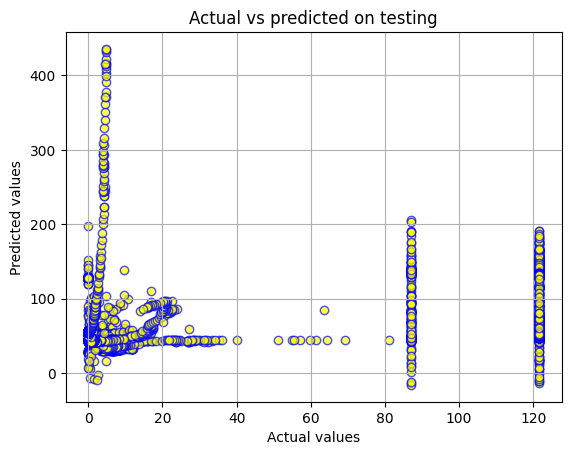

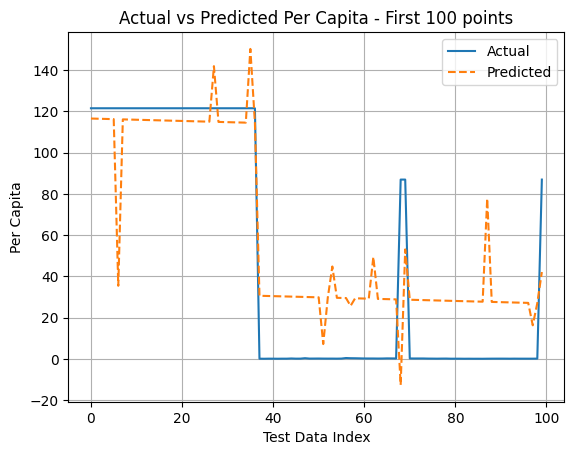

In [30]:
# plotting prediction vs actual targets
yTestPrediction = np.dot(X_test_normalized, weight)
plt.scatter(y_test, yTestPrediction, alpha=0.7, edgecolors='b', color='yellow')
plt.title("Actual vs predicted on testing")
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.grid(True)
plt.show()

plt.plot(y_test[:100], label='Actual')
plt.plot(yTestPrediction[:100], label='Predicted', linestyle='--')
plt.title('Actual vs Predicted Per Capita - First 100 points')
plt.xlabel('Test Data Index')
plt.ylabel('Per Capita')
plt.legend()
plt.grid(True)
plt.show()


Referenced used:
1. https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.apply.html#pandas.DataFrame.apply
2. https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html
3. https://matplotlib.org/stable/users/explain/quick_start.html
4. https://medium.com/@pp1222001/outlier-detection-and-removal-using-the-iqr-method-6fab2954315d
5. https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html
6. https://medium.com/@msoczi/ridge-regression-step-by-step-introduction-with-example-0d22dddb7d54